In [1]:
from collections import defaultdict
from pathlib import Path
import os
import numpy as np
import math
from DMTimeShardDataset import DMTimeShardDataset
import torch
from training import label_encoding
from torch.utils.data import DataLoader
from training_models import models_htable
import training_models
import matplotlib.pyplot as plt


from rejector import Rejector, EmbeddingRejector
from skrejector import SNRDT_Rejector
import torch.nn as nn
from embedding_processing_models import build_embedding_processing

In [2]:
def get_snr_bins(metadata_path, labels_path, save_pulsars_only):
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"Metadata file not found at {metadata_path}")
    if not os.path.exists(labels_path):
        raise FileNotFoundError(f"Labels file not found at {labels_path}")

    metadata = np.load(metadata_path)
    labels = np.load(labels_path)
    if metadata.ndim != 2 or metadata.shape[1] < 1:
        raise ValueError("Expected metadata with shape (N, >=1) where column 0 stores SNR values.")
    if metadata.shape[0] != labels.shape[0]:
        raise ValueError(f"Label count ({labels.shape[0]}) does not match metadata count ({metadata.shape[0]}).")
        
    print("metadata length: ", len(metadata), "labels length: ", len(labels))
    if metadata.size == 0:
        return {}
        
    snr_values = metadata[:, 0]
    snr_bins = defaultdict(list)
    
    for idx, snr_value in enumerate(snr_values):
        is_finite = np.isfinite(snr_value)
        rounded_bin = int(np.rint(float(snr_value))) if is_finite else None
        
        if save_pulsars_only and labels[idx] != "Pulse":
            continue
        
        snr_bins[rounded_bin].append(idx)
        
    finite_keys = sorted([key for key in snr_bins.keys() if key is not None])
    ordered_bins = {key: snr_bins[key] for key in finite_keys}
    if None in snr_bins:
        ordered_bins[None] = snr_bins[None]
        
    print(f"Created {len(ordered_bins)} SNR bins from {len(snr_values)} samples.")
    return ordered_bins

In [ ]:
def evaluate_rejector_for_snrs(
    f_small,
    f_large,
    rejector,
    snr_bins,
    data_path,
    labels_path,
    batch_size=512,
    num_workers=8,
    use_freq_time=True,
    split="val",
    device=None,
    positive_label=1,
    zero_division=0.0,
):
    def _infer_prefix(labels_path_: str) -> str:
        labels_name = os.path.basename(labels_path_)
        suffixes = [
            "_DM_time_dataset_realbased_labels_test.npy",
            "_DM_time_dataset_realbased_labels_train.npy",
            "_DM_time_dataset_realbased_labels_val.npy"
        ]
        for suffix in suffixes:
            if labels_name.endswith(suffix):
                return labels_name[: -len(suffix)]
        return Path(labels_name).stem

    def _compute_metrics(tp, fp, fn, tn):
        total = tp + fp + fn + tn
        accuracy = (tp + tn) / total if total else float("nan")
        precision = tp / (tp + fp) if (tp + fp) else zero_division
        recall = tp / (tp + fn) if (tp + fn) else zero_division
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall > 0) else zero_division
        return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1, "count": total}

    def _format_metric(value):
        return f"{value:.4f}" if math.isfinite(value) else "   nan"

    data_root = Path(data_path)
    if data_root.is_file(): data_root = data_root.parent

    dataset_cfg = {"output_dir": str(data_root), "prefix": _infer_prefix(str(labels_path))}
    
    full_dataset = DMTimeShardDataset(dataset_cfg, use_freq_time=use_freq_time, split=split)
    full_dataset.labels = label_encoding(full_dataset.labels.astype(object))
    dataset_len = len(full_dataset)

    target_device = device or torch.device("cuda")
    
    f_small.eval()
    f_large.eval()
    if hasattr(rejector, "eval"):
        rejector.eval()

    bin_results = {}
    overall_counts = {"tp": 0, "fp": 0, "fn": 0, "tn": 0}

    def _bin_sort_key(item):
        key, _ = item
        return (float("inf"), 0) if key is None else (0, key)

    with torch.no_grad():
        for snr_value, indices in sorted(snr_bins.items(), key=_bin_sort_key):
            valid_indices = [idx for idx in indices if idx < dataset_len]
            if not valid_indices: continue

            subset = torch.utils.data.Subset(full_dataset, valid_indices)
            loader = DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

            counts = {"tp": 0, "fp": 0, "fn": 0, "tn": 0}
            for batch in loader:
                batch_on_device = {k: v.to(target_device) if torch.is_tensor(v) else v for k, v in batch.items()}
                labels = batch_on_device["label"]
                
                # Wahre Routing-Targets generieren: 
                # 1 (Reject) nur wenn f_small falsch liegt UND f_large richtig liegt.
                # Wenn beide Modelle falsch liegen, lohnt sich der Wechsel nicht -> 0
                preds_small = f_small.forward(batch_on_device).argmax(dim=1)
                #preds_large = f_large.forward(batch_on_device).argmax(dim=1)
                #routing_targets = ((preds_small != labels) & (preds_large == labels)).long()
                routing_targets = (preds_small != labels)
                
                if isinstance(rejector, SNRDT_Rejector):
                    predictions = rejector.predict(batch_on_device)
                    predictions = predictions.to(target_device) if torch.is_tensor(predictions) else torch.tensor(predictions, device=target_device)
                elif isinstance(rejector, EmbeddingRejector):
                    predictions = rejector.predict_proba(batch_on_device).argmax(dim=1)
                else:
                    inputs = rejector.prepare_inputs(batch_on_device, f_small.features(batch_on_device))
                    predictions = rejector.predict_proba(inputs).argmax(dim=1)

                positive_pred = predictions == positive_label
                positive_true = routing_targets == positive_label

                counts["tp"] += torch.logical_and(positive_pred, positive_true).sum().item()
                counts["fp"] += torch.logical_and(positive_pred, ~positive_true).sum().item()
                counts["fn"] += torch.logical_and(~positive_pred, positive_true).sum().item()
                counts["tn"] += torch.logical_and(~positive_pred, ~positive_true).sum().item()

            metrics = _compute_metrics(**counts)
            bin_results[snr_value] = {**metrics, **counts}
            for k in overall_counts: overall_counts[k] += counts[k]

            snr_str = "None" if snr_value is None else str(snr_value)
            print(f"SNR={snr_str:<8}: samples={metrics['count']:5d}, acc={_format_metric(metrics['accuracy'])} prec={_format_metric(metrics['precision'])} rec={_format_metric(metrics['recall'])} f1={_format_metric(metrics['f1'])}")

    overall_metrics = _compute_metrics(**overall_counts)
    print("-" * 60)
    print(f"Overall across {overall_metrics['count']} samples -> acc={_format_metric(overall_metrics['accuracy'])}, prec={_format_metric(overall_metrics['precision'])}, rec={_format_metric(overall_metrics['recall'])}, f1={_format_metric(overall_metrics['f1'])}")

    return {"per_bin": bin_results, "overall": {**overall_metrics, **overall_counts}}

In [4]:
def plot_snr_curves(snr_evaluations, SNR_end=None, include_non_finite=False):
    def _sort_key(item):
        key, _ = item
        return (float("inf"), 0) if key is None else (0, key)
    
    for snr_evaluation in snr_evaluations:
        per_bin = snr_evaluation["per_bin"]
        if SNR_end is not None and SNR_end > 0:
            per_bin = {k: v for k, v in per_bin.items() if k is not None and k <= SNR_end}
        
        metric_names = ["accuracy", "precision", "recall", "f1"]
        style_cycle = {
            "accuracy": {"marker": "o", "linestyle": "-", "color": "#1f77b4"},
            "precision": {"marker": "s", "linestyle": "--", "color": "#ff7f0e"},
            "recall": {"marker": "D", "linestyle": "-.", "color": "#2ca02c"},
            "f1": {"marker": "^", "linestyle": ":", "color": "#d62728"},
        }

        snr_values = []
        metrics_by_name = {name: [] for name in metric_names}

        for snr_value, metrics in sorted(per_bin.items(), key=_sort_key):
            if snr_value is None and not include_non_finite: continue
            snr_values.append(snr_value if snr_value is not None else -1)
            for name in metric_names:
                metrics_by_name[name].append(metrics.get(name, float("nan")))

        fig, ax = plt.subplots(figsize=(7, 5))
        for name in metric_names:
            ax.plot(snr_values, metrics_by_name[name], label=name.capitalize(), **style_cycle.get(name, {}))

    ax.set_xlabel("SNR")
    ax.set_ylabel("Score (Predicting 'f_small will fail')")
    ax.set_title("Rejector Performance vs. SNR")
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(loc="lower right")
    plt.tight_layout()
    return ax

In [5]:
# Setup Daten und Bins laden
dataset_split = "val"
metadata_path = Path("/cephfs/users/oleksjuk/MA/WP2-1/DM_time_dataset_creator/outputs/B0531+21_59000_48386_DM_time_dataset_realbased_metadata_val.npy")
labels_path = Path("/cephfs/users/oleksjuk/MA/WP2-1/DM_time_dataset_creator/outputs/B0531+21_59000_48386_DM_time_dataset_realbased_labels_val.npy")
data_path = Path("/cephfs/users/oleksjuk/MA/WP2-1/DM_time_dataset_creator/outputs")
device = "cuda" if torch.cuda.is_available() else "cpu"

snr_bins_test = get_snr_bins(str(metadata_path), str(labels_path), save_pulsars_only=False)

metadata length:  172032 labels length:  172032
Created 26 SNR bins from 172032 samples.
Created 26 SNR bins from 172032 samples.


In [ ]:
# f_small und f_large laden
small_weights = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_3_GAP-014-0.764-0.740.pth"
f_small = training_models.models_htable["DM_time_binary_classificator_241002_3_GAP"](256, mode="dmt", dropout=False, device=device).to(device)
f_small.load_state_dict(torch.load(small_weights, map_location=device)["model_state_dict"])
f_small.eval()

large_weights = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_resnet18-003-0.993-0.993.pth"
f_large = training_models.models_htable["DM_time_binary_classificator_241002_5_GAP"](256, mode="ft", dropout=False, device=device).to(device)
f_large.load_state_dict(torch.load(large_weights, map_location=device)["model_state_dict"])
f_large.eval()

###############################
# rejector laden

rejector_type = "embedding"

rejector_path = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_checkpoints/prot-run_embedding_3_GAP_pooled_mlp_lr8.55e-04_wd1.32e-05_drop0.0_hidden128_worker14_trial0-020-0.608-0.593.pth"

if rejector_type == "embedding":
    embedding_model = "pooled_mlp"  # conv_gap, conv_mlp, spatial_pool_mlp, pooled_mlp, pooled_mlp_128_64, pooled_mlp_256_256
    cnn_channels = 64
    extra_conv = True
    pool_size = 5
    hidden_dim = 128
    dropout = 0.0

    embedding_processing, feature_source = build_embedding_processing(
        embedding_model,
        in_channels=f_small.out_features,
        cnn_channels=cnn_channels,
        extra_conv=extra_conv,
        pool_size=pool_size,
        hidden_dim=hidden_dim,
        dropout=dropout,
    )
    embedding_processing = embedding_processing.to(device)

    rejector = EmbeddingRejector(
        f_small,
        embedding_processing,
        device,
        feature_source=feature_source,
    )

    checkpoint = torch.load(rejector_path, map_location=device)
    state_dict = checkpoint.get("model_state_dict", checkpoint)

    try:
        rejector.model.load_state_dict(state_dict)
        print("Rejector geladen über rejector.model.load_state_dict(...)")
    except RuntimeError:
        rejector.embedding_processing.load_state_dict(state_dict)
        print("Rejector geladen über rejector.embedding_processing.load_state_dict(...)")

    print(f"Embedding Rejector: {embedding_model} | feature_source={feature_source}")

elif rejector_type == "snrdt":
    rejector = SNRDT_Rejector(device)
    #todo

Rejector geladen über rejector.model.load_state_dict(...)
Embedding Rejector: pooled_mlp | feature_source=pooled_features


Converting string labels to numeric: ['Artefact' 'Pulse'] -> [0, 1]
SNR=3       : samples=  256, acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000
SNR=3       : samples=  256, acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000
SNR=4       : samples=42240, acc=0.5328 prec=0.6644 rec=0.5189 f1=0.5827
SNR=4       : samples=42240, acc=0.5328 prec=0.6644 rec=0.5189 f1=0.5827
SNR=5       : samples=23552, acc=0.6179 prec=0.5496 rec=0.6475 f1=0.5946
SNR=5       : samples=23552, acc=0.6179 prec=0.5496 rec=0.6475 f1=0.5946
SNR=6       : samples= 6656, acc=0.9138 prec=0.5679 rec=0.8932 f1=0.6944
SNR=6       : samples= 6656, acc=0.9138 prec=0.5679 rec=0.8932 f1=0.6944
SNR=7       : samples= 3328, acc=0.9612 prec=0.4901 rec=0.7920 f1=0.6055
SNR=7       : samples= 3328, acc=0.9612 prec=0.4901 rec=0.7920 f1=0.6055
SNR=8       : samples= 3328, acc=0.9742 prec=0.6296 rec=0.8815 f1=0.7346
SNR=8       : samples= 3328, acc=0.9742 prec=0.6296 rec=0.8815 f1=0.7346
SNR=10      : samples=  512, acc=0.9727 prec=0.2632 rec=

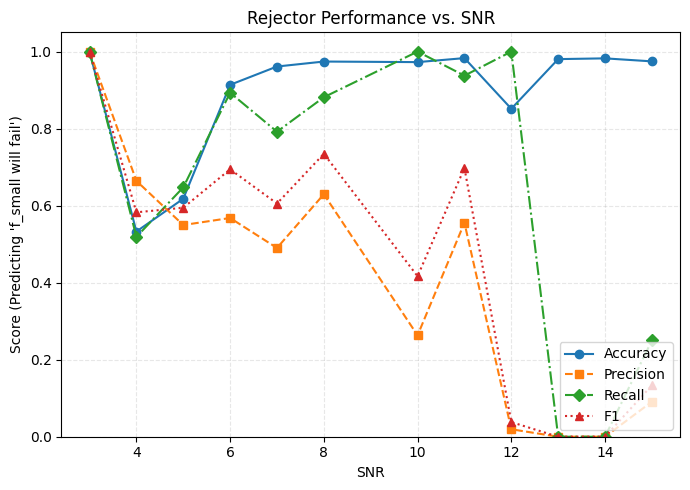

In [ ]:
# rejector evaluieren
eval_results = evaluate_rejector_for_snrs(
    f_small=f_small,
    f_large=f_large,
    rejector=rejector,
    snr_bins=snr_bins_test,
    data_path=data_path,
    labels_path=labels_path,
    split="val",
    device=device
)

plot_snr_curves([eval_results], SNR_end=15)
plt.show()

In [ ]:
print("old routing target balancing test")

metadata = np.load(metadata_path)
all_snrs = metadata[:, 0]

data_root = Path(data_path)
if data_root.is_file(): data_root = data_root.parent
dataset_cfg = {"output_dir": str(data_root), "prefix": "B0531+21_59000_48386"}
full_dataset = DMTimeShardDataset(dataset_cfg, use_freq_time=True, split="val")
full_dataset.labels = label_encoding(full_dataset.labels.astype(object))

loader = DataLoader(full_dataset, batch_size=512, shuffle=False, num_workers=4)

all_preds_small = []
all_labels = []
all_preds_large = []

f_small.eval()
f_large.eval()

with torch.no_grad():
    for batch in loader:
        b_dev = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
        logits_small = f_small.forward(b_dev)
        
        all_preds_small.append(logits_small.cpu().numpy())
        all_labels.append(b_dev["label"].cpu().numpy())
        
        logits_large = f_large.forward(b_dev)
        all_preds_large.append(logits_large.cpu().numpy())

preds_small = np.concatenate(all_preds_small, axis=0)
labels = np.concatenate(all_labels, axis=0)
preds_large = np.concatenate(all_preds_large, axis=0)

# compute routing targets
pred_classes_small = preds_small.argmax(axis=1)
pred_classes_large = preds_large.argmax(axis=1)
routing_targets = ((pred_classes_small != labels) & (pred_classes_large == labels)).astype(int)

from scipy.special import softmax

pulse_probs = softmax(preds_small, axis=1)

idx_0 = np.where(routing_targets == 0)[0]
idx_1 = np.where(routing_targets == 1)[0]

n0 = len(idx_0)
n1 = len(idx_1)
n_per_class = min(n0, n1)

pulse_zero_probs = pulse_probs[idx_0]
pulse_zero_conf = pulse_zero_probs.max(axis=1) # max-Confidence

# old sorting
pulse_zero_sorted_rel = pulse_zero_conf.argsort()
pulse_zero_selected_rel = pulse_zero_sorted_rel[:n_per_class]
pulse_zero_selected_idx = idx_0[pulse_zero_selected_rel] #  retained no reject samples


snrs_of_class_0_original = all_snrs[idx_0]
snrs_of_class_0_kept = all_snrs[pulse_zero_selected_idx]

original_noise_count = np.sum(np.isnan(snrs_of_class_0_original))
kept_noise_count = np.sum(np.isnan(snrs_of_class_0_kept))

print(f"Total Target=0 (NO REJECT) samples before balancing: {n0}")
print(f"Total Target=1 (REJECT) samples before balancing: {n1}")
print(f"Wir behalten also {n_per_class} Samples von Target=0.")
print("-" * 30)
print(f"Reines Rauschen (SNR=NaN) in Target=0 VOR dem Cut: {original_noise_count}")
print(f"Reines Rauschen (SNR=NaN) in Target=0 NACH dem Cut: {kept_noise_count}")
print(f"Prozentualer Verlust an Noise-Daten: {(1 - kept_noise_count/(original_noise_count+1e-9))*100:.2f}%")

--- Simulation von _splitTrainData (Hard Negative Mining) auf dem GESAMTEN Datensatz ---
Converting string labels to numeric: ['Artefact' 'Pulse'] -> [0, 1]
Converting string labels to numeric: ['Artefact' 'Pulse'] -> [0, 1]


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x75f51399d630>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1478, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1461, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
<function _MultiProcessingDataLoaderIter.__del__ at 0x75f51399d630>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1478, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1461, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
Assert

Total Target=0 (NO REJECT) samples before balancing: 132209
Total Target=1 (REJECT) samples before balancing: 39823
Wir behalten also 39823 Samples von Target=0.
------------------------------
Reines Rauschen (SNR=NaN) in Target=0 VOR dem Cut: 84030
Reines Rauschen (SNR=NaN) in Target=0 NACH dem Cut: 26255
Prozentualer Verlust an Noise-Daten: 68.76%
